1\. **PCA on 3D dataset**

* Generate a dataset with 3 features each with N entries (N being ${\cal O}(1000)$). With $N(\mu,\sigma)$ the normali distribution with mean $\mu$ and $\sigma$  standard deviation, generate the 3 variables $x_{1,2,3}$ such that:
    * $x_1$ is distributed as $N(0,1)$
    * $x_2$ is distributed as $x_1+N(0,3)$
    * $x_3$ is given by $2x_1+x_2$
* Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
* Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result
* What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
* Redefine the data in the basis yielded by the PCA procedure
* Plot the data points in the original and the new coordiantes as a set of scatter plots. Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) proejctions.


In [1]:
import numpy as np
import pandas as pd
from scipy import linalg as la

In [2]:
# Generate a dataset
np.random.seed(123)

N=1000
x1 = np.random.normal(0, 1, N)
x2 = x1 + np.random.normal(0, 3, N)
x3 = 2*x1 + x2

df = pd.DataFrame({'x1':x1, 'x2':x2, 'x3':x3})

In [4]:
# Find the eigenvectors and eigenvalues of the covariance matrix of the dataset

cov_matrix = df.cov()
evals, evecs = la.eig(cov_matrix)

idx = evals.argsort()[::-1] # indices de menor a mayor y luego invertimos
evals = evals[idx]
evecs = evecs[:, idx]

print(evals)
print(evecs)

[2.48444042e+01+0.j 2.00001118e+00+0.j 1.66886524e-16+0.j]
[[-0.12126076  0.56447246 -0.81649658]
 [-0.57007399 -0.71298596 -0.40824829]
 [-0.81259551  0.41595897  0.40824829]]


In [4]:
# Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result

U, S, Vt = la.svd(df-df.mean())
evals_svd = (S**2)/(N-1)
evecs_svd = Vt.T

print(evals_svd)
print(evecs_svd)

[2.48444042e+01 2.00001118e+00 1.58620777e-31]
[[ 0.12126076 -0.56447246  0.81649658]
 [ 0.57007399  0.71298596  0.40824829]
 [ 0.81259551 -0.41595897 -0.40824829]]


In [5]:
# What percent of the total dataset's variability is explained by the principal components? 
v = evals*100 / np.sum(evals)
v
# The principal components explain (approx) 93%, 7%, and 0% of the total variability.

#Given how the dataset was constructed, do these make sense?
# Yes, because the dataset was constructed in such a way that the third variable is a linear combination of the first two. 
# Therefore, there is no new information in the third dimension, and the variability is entirely concentrated in the first two.

#Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
# with the two first componentes 99% of the total variability is exlained.

array([9.25496191e+01+0.j, 7.45038085e+00+0.j, 6.21680604e-16+0.j])

In [6]:
# Redefine the data in the basis yielded by the PCA procedure

# change of base
x_pca = df.values @ evecs

# Convertirlo a un DataFrame para trabajar con él
df_pca = pd.DataFrame(x_pca, columns=['PC1', 'PC2', 'PC3'])
print(df_pca.head())

df_reduced = df_pca[['PC1', 'PC2']]
print("Dimensionality Reduction:")
print(df_reduced.head())

        PC1       PC2           PC3
0  6.503213 -0.526237  1.776357e-15
1 -5.475203  0.590672 -1.332268e-15
2 -3.864369 -0.328834 -4.440892e-16
3  8.858819 -0.765436  1.776357e-15
4 -0.159372 -1.059265  5.828671e-16
Dimensionality Reduction:
        PC1       PC2
0  6.503213 -0.526237
1 -5.475203  0.590672
2 -3.864369 -0.328834
3  8.858819 -0.765436
4 -0.159372 -1.059265


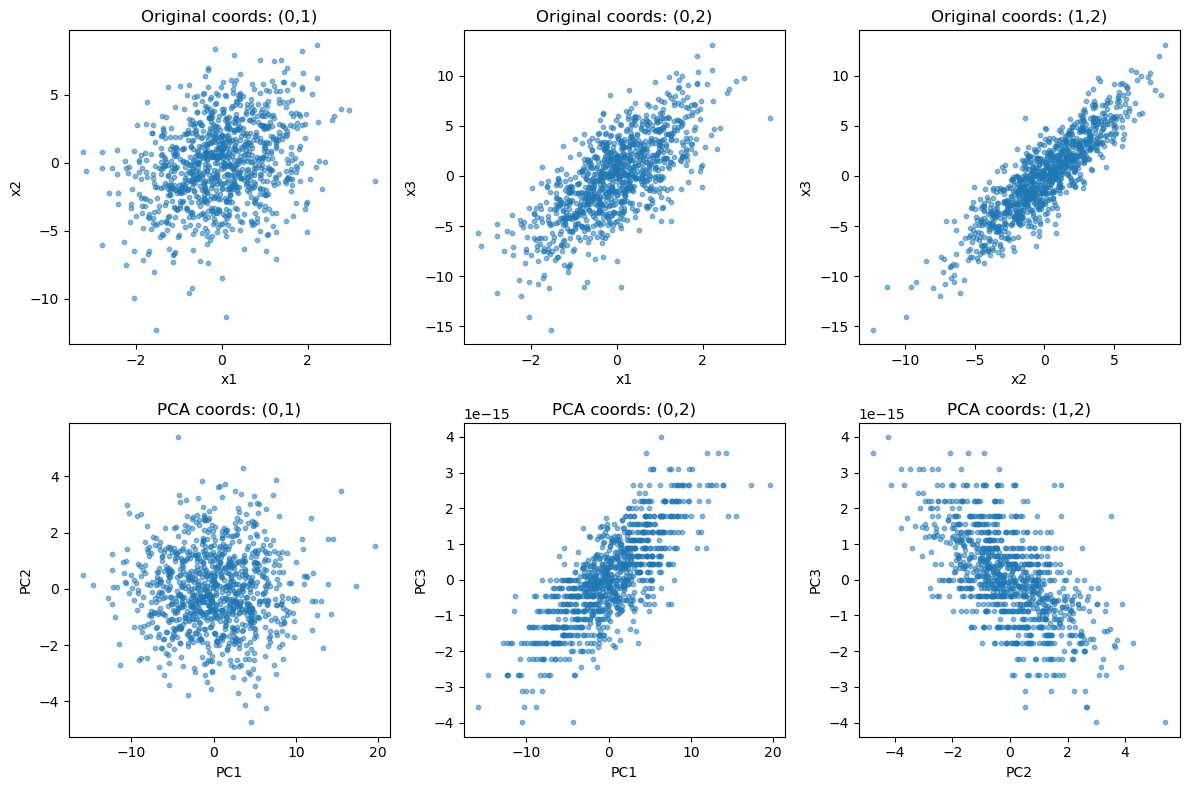

In [7]:
# Plot the data points in the original and the new coordiantes as a set of scatter plots. 
# Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) projections.
import matplotlib.pyplot as plt

datasets = [
    (df.values, ["x1","x2","x3"], "Original"),
    (df_pca.values, ["PC1","PC2","PC3"], "PCA")
]

pairs = [(0,1), (0,2), (1,2)]

fig, axes = plt.subplots(2, 3, figsize=(12,8))

for r, (X, labels, title) in enumerate(datasets):
    for c, (i, j) in enumerate(pairs):
        ax = axes[r, c]
        ax.scatter(X[:, i], X[:, j], s=10, alpha=0.5)
        ax.set_xlabel(labels[i])
        ax.set_ylabel(labels[j])
        ax.set_title(f"{title} coords: ({i},{j})")
        #ax.set_xlim(-20,20)
        #ax.set_ylim(-15,15)

plt.tight_layout()
plt.show()

2\. **PCA on a nD dataset**

Start from the dataset you have genereted in the previous exercise and add uncorrelated random noise. Such noise should be represented by other 10 uncorrelated variables normal distributed, with standar deviation much smaller (say, a factor 50) than those used to generate the $x_1$ and $x_2$.

Repeat the PCA procedure and compare the results with what you obtained before

In [3]:
np.random.seed(123)

noise_std = 1/50 
noise = np.random.normal(0, noise_std, size=(N,10)) # size=(N,10) crea una matriz de N filas, 10 columnas

noise_cols = [f'n{i+1}' for i in range(10)]
df_noise = pd.DataFrame(noise, columns=noise_cols)

new_df = pd.concat([df, df_noise], axis=1)
print(new_df.head())

         x1        x2        x3        n1        n2        n3        n4  \
0 -1.085631 -3.332113 -5.503374 -0.021713  0.019947  0.005660 -0.030126   
1  0.997345  2.700130  4.694821 -0.013578 -0.001894  0.029828 -0.012778   
2  0.282978  2.437430  3.003387  0.014747  0.029815 -0.018717  0.023517   
3 -1.506295 -4.504437 -7.517026 -0.005112 -0.055972 -0.035431 -0.013998   
4 -0.578600  0.846095 -0.311106 -0.016107 -0.034553 -0.007818  0.011476   

         n5        n6        n7        n8        n9       n10  
0 -0.011572  0.033029 -0.048534 -0.008578  0.025319 -0.017335  
1 -0.008880 -0.008687  0.044119  0.043736  0.020081  0.007724  
2 -0.025078 -0.012755  0.018142 -0.028574 -0.002801 -0.017235  
3  0.018549 -0.003473  0.000057  0.013764 -0.017591  0.005673  
4  0.006772 -0.000237  0.047847  0.008258  0.019575  0.044763  


In [6]:
cov_matrix = new_df.cov()
evals, evecs = la.eig(cov_matrix)

idx = evals.argsort()[::-1] # indices de menor a mayor y luego invertimos
evals = evals[idx]
evecs = evecs[:, idx]

#print(evals)
#print(evecs)

In [20]:
v = evals*100 / np.sum(evals)
print(v)

[9.25358965e+01+0.j 7.44928675e+00+0.j 1.74355291e-03+0.j
 1.67410774e-03+0.j 1.59389467e-03+0.j 1.56676628e-03+0.j
 1.52994342e-03+0.j 1.48954069e-03+0.j 1.38243392e-03+0.j
 1.31981021e-03+0.j 1.27512047e-03+0.j 1.24161798e-03+0.j
 6.10279691e-15+0.j]


In [21]:
# change of base
new_x_pca = new_df.values @ evecs

new_df_pca = pd.DataFrame(new_x_pca, columns=[f'PC{i}' for i in range(1,14)])
print(new_df_pca.head())

        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0  6.503212  0.526220 -0.010747 -0.036373 -0.002750  0.019417 -0.022812   
1 -5.475195 -0.590684  0.012728  0.009425  0.020557  0.001326  0.059561   
2 -3.864369  0.328830  0.030736 -0.001066 -0.004073 -0.006531 -0.039508   
3  8.858824  0.765462 -0.008268  0.023793 -0.005645  0.022680  0.013315   
4 -0.159367  1.059233 -0.002634 -0.007032 -0.004043  0.027340  0.053932   

        PC8       PC9      PC10      PC11      PC12          PC13  
0  0.004864 -0.009779  0.023969  0.010641 -0.057276  4.762930e-16  
1 -0.018168 -0.004345  0.033371 -0.007675  0.006559 -6.437864e-16  
2 -0.019444  0.020365  0.008775  0.008164  0.027439 -1.021120e-15  
3  0.016037 -0.012106 -0.043467 -0.041392 -0.001822  8.320648e-16  
4 -0.020931 -0.004038 -0.022087 -0.010323  0.041554 -8.683918e-16  


3 \. **Looking at an oscillating spring** (optional)

Imagine you have $n$ cameras looking at a spring oscillating along the $x$ axis. Each  camera record the motion of the spring looking at it along a given direction defined by the pair $(\theta_i, \phi_i)$, the angles in spherical coordinates. 

Start from the simulation of the records (say ${\cal O}(1000)$) of the spring's motion along the x axis, assuming a little random noise affects the measurements along the $y$. Rotate such dataset to emulate the records of each camera.

Perform a Principal Component Analysis on the thus obtained dataset, aiming at finding the only one coordinate that really matters.


4\. **PCA on the MAGIC dataset** (optional)

Perform a PCA on the magic04.data dataset

In [12]:
# get the dataset and its description on the proper data directory
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data -P ~/data/
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.names -P ~/data/ 

--2026-02-03 18:34:32--  https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data
128.195.10.252ive.ics.uci.edu (archive.ics.uci.edu)... 
connected. to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... 
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/home/gaby/data/magic04.data.3’

magic04.data.3          [     <=>            ]   1,41M  95,1KB/s    in 11s     

2026-02-03 18:34:45 (130 KB/s) - ‘/home/gaby/data/magic04.data.3’ saved [1477391]

--2026-02-03 18:34:45--  https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.names
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
connected. to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... 
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/home/gaby/data/magic04.names.3’

magic04.names.3         [ <=>                ]   5,27K  --.-KB/s    in 0s      

2026-02-03 18:34:47 (87,4 MB/s) - ‘/hom